# Post-Processing Pipeline Walkthrough

This notebook walks you through the post-processing pipeline: fitting population Receptive Field (pRF) models and Connective Field (CF) models to denoised surface timeseries, then collating everything into a single analysis CSV.

### What this pipeline produces
Starting from the denoised surface GIFTIs produced by the functional pipeline, we end up with:
- Gaussian pRF parameters per vertex (eccentricity, polar angle, size, amplitude, R²)
- Connective field parameters per vertex (CF centre, CF size, R²)
- A combined CSV per subject collating pRF fits, CF fits, and Benson14 atlas values

### Pipeline stages at a glance
| Stage | Script | What it does |
|-------|--------|--------------|
| Pre | `project_###.yml` + `project_###_dm.npy` | Settings + design matrix (you create these once) |
| 1 | `s01_gauss_prfpy.py` | Gaussian pRF fitting (grid + iterative) |
| 2 | `s02_prf_visualize.ipynb` | Interactive pRF visualisation |
| 3 | `s03_cf_prfpy.py` | Connective field fitting (grid fit) |
| 4 | `s04_collate_analyses.py` | Merge pRF, CF, and Benson14 into one CSV |

### Prerequisites
- The **functional pipeline** must have been completed — denoised surface GIFTIs in `derivatives/s4_denoised/`
- The **anatomical pipeline** must have been completed — FreeSurfer reconstruction + Benson14 labels
- `PIPELINE_DIR` set in your `~/.bash_profile`
- Your `config/project_<name>.sh` file is set up
- A `postproc/project_<name>.yml` settings file and `postproc/project_<name>_dm.npy` design matrix (see Step 0 below)

---

## 0. Set your variables

Fill in the cell below then **run it once**. It sources the project config and exposes all environment variables to subsequent bash cells.

In [2]:
import subprocess, os
from cvl_utils.preproc_func import set_project
# ── Fill these in ────────────────────────────────────────────────────────────
PROJECT = 'lhon'    # matches your config/project_<name>.sh file
SUB     = 'sub-C001'  # subject label, e.g. sub-01
SES     = 'ses-prf'  # session containing the T1w scan, e.g. ses-01
TASK    = 'prfNonEq'
# ─────────────────────────────────────────────────────────────────────────────
# Source the project config once and capture every exported variable into
# os.environ so all %%bash cells below pick them up without re-sourcing.
set_project(PROJECT)
os.environ['SUB']  = SUB
os.environ['SES']  = SES
os.environ['TASK'] = TASK
os.environ['PROJECT'] = PROJECT
print(f"Project:     {os.environ.get('PROJ_NAME')}")
print(f"BIDS dir:    {os.environ.get('BIDS_DIR')}")
print(f"FreeSurfer:  {os.environ.get('SUBJECTS_DIR')}")
print(f"AFNI image:  {os.environ.get('AFNI_IMAGE')}")
print(f"FSL image:   {os.environ.get('FSL_FREESURFER_IMAGE')}")
print(f"Subject:     {os.environ.get('SUB')}")
print(f"Session:     {os.environ.get('SES')}")
print(f"Task:        {os.environ.get('TASK') or '<all tasks>'}")

Project:     lhon
BIDS dir:    /Users/marcusdaghlian/projects/lhon_sl
FreeSurfer:  /Users/marcusdaghlian/projects/lhon_sl/derivatives/freesurfer
CTX dir:     (not set)
Project:     lhon
BIDS dir:    /Users/marcusdaghlian/projects/lhon_sl
FreeSurfer:  /Users/marcusdaghlian/projects/lhon_sl/derivatives/freesurfer
AFNI image:  vnmd/afni_26.0.07
FSL image:   ndock_fsl_freesurfer:latest
Subject:     sub-C001
Session:     ses-prf
Task:        prfNonEq


---
## Step 0 — Prerequisites: Settings File & Design Matrix

Before running any fitting you need two files in the `postproc/` directory:

### 1. Settings YAML — `project_<name>.yml`
This file tells the fitting scripts about your experimental setup and fitting hyperparameters. It is loaded by name using the `--project` argument. An example (`eg_prf_settings.yml`) lives in the `postproc/` folder. Copy and rename it for your project:

```
postproc/
├── eg_prf_settings.yml          ← reference example
└── project_hypot.yml            ← your project-specific settings
```

Key fields to set:

| Field | What it controls |
|-------|------------------|
| `TR` | Repetition time of your BOLD sequence (seconds) |
| `psc_baseline` | How many volumes at the start of each run have **no stimulation** — used to set the %signal-change baseline |
| `vols_to_chop` | How many leading volumes to discard so the BOLD timeseries aligns with the design matrix |
| `screen_size_cm` | Physical height of your stimulus screen (cm) |
| `screen_distance_cm` | Distance from the subject's eye to the screen (cm) |
| `grid_nr` | Grid resolution for the grid fit — higher = more accurate but slower |
| `hrf.pars` | HRF coefficients `[canonical, derivative, dispersion]` |
| `sigma_grid` | List of CF sizes (degrees) to search over during CF grid fit |

### 2. Design matrix — `project_<name>_dm.npy`
This is a NumPy array of shape `(n_pixels × n_pixels × n_timepoints)` describing which pixels of the screen were illuminated at each TR. **n_timepoints must match the number of volumes in your (chopped) BOLD timeseries.**

The design matrix is experiment-specific and is typically generated from your stimulus presentation logs. An example (`eg_prf_dm.npy`) is included for reference.

> **Important:** if you have multiple pRF task variants (e.g. `pRFLE` and `pRFRE`) you need one design matrix per task, named `project_<name>_<task>_dm.npy`. Check `cvl_utils.prfpy_utils.get_dm_and_settings` for the exact naming convention.

In [3]:
%%bash
# copy over existing ones...
cp ${PIPELINE_DIR}/postproc/eg_prf_dm.npy ${PIPELINE_DIR}/postproc/project_${PROJECT}_dm.npy
cp ${PIPELINE_DIR}/postproc/eg_prf_settings.yml ${PIPELINE_DIR}/postproc/project_${PROJECT}.yml


In [4]:
%%bash
# ── Check that the settings file and design matrix exist ──────────────────────
echo "=== Settings files ==="
ls "${PIPELINE_DIR}/postproc/"project_*.yml 2>/dev/null || echo "  No project_*.yml found"

echo ""
echo "=== Design matrices ==="
ls "${PIPELINE_DIR}/postproc/"project_*_dm.npy 2>/dev/null || echo "  No project_*_dm.npy found"

echo ""
echo "=== Input surface data (s3_denoised) ==="
ls "${BIDS_DIR}/derivatives/s3_denoised/${SUB}/${SES}/"*denoised_bold.func.gii 2>/dev/null \
    | head -6 || echo "  No denoised surface files found — complete the functional pipeline first"

=== Settings files ===
/Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/code/hypot_code//postproc/project_hypot.yml
/Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/code/hypot_code//postproc/project_lhon.yml

=== Design matrices ===
/Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/code/hypot_code//postproc/project_hypot_dm.npy
/Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/code/hypot_code//postproc/project_lhon_dm.npy

=== Input surface data (s3_denoised) ===
/Users/marcusdaghlian/projects/lhon_sl/derivatives/s3_denoised/sub-C001/ses-prf/sub-C001_ses-prf_task-prfNonEq_run-1_space-fsnative_hemi-L_desc-denoised_bold.func.gii
/Users/marcusdaghlian/projects/lhon_sl/derivatives/s3_denoised/sub-C001/ses-prf/sub-C001_ses-prf_task-prfNonEq_run-1_space-fsnative_hemi-R_desc-denoised_bold.func.gii
/Users/marcusdaghlian/projects/lhon_sl/derivatives/s3_denoised/sub-C001/ses-prf/sub-C001_ses-prf_task-prfNonEq_run-2_space-fsnative_hemi-L_desc-denoised_bol

### Inspect the design matrix

It is always worth visualising the design matrix before fitting to make sure the timing and pixel content look correct.

Loaded: project_lhon_dm.npy
Shape: (100, 100, 348)  (pixels × pixels × timepoints)


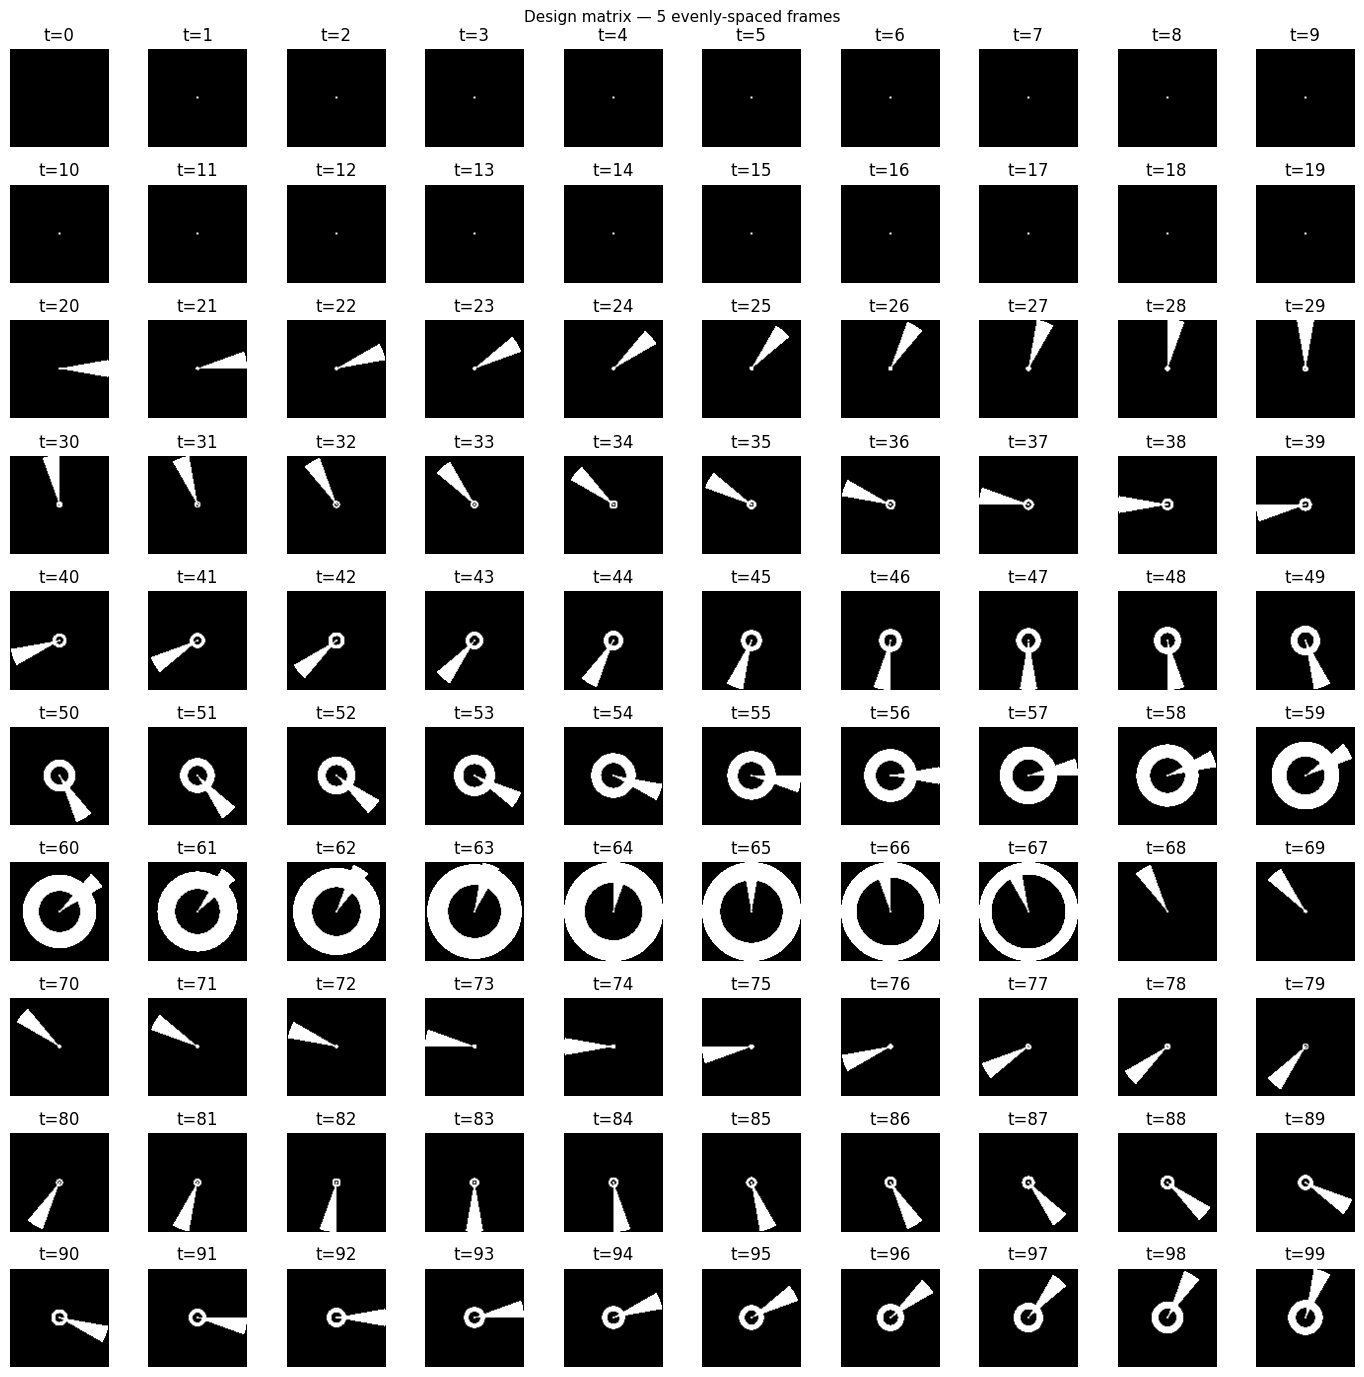

In [7]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

pipeline_dir = os.environ.get('PIPELINE_DIR', '')
project      = os.environ.get('PROJECT', '')
prf_task     = os.environ.get('PRF_TASK', '')

# The naming convention: project_<name>_<task>_dm.npy or project_<name>_dm.npy
dm_candidates = [
    os.path.join(pipeline_dir, 'postproc', f'project_{project}_{prf_task}_dm.npy'),
    os.path.join(pipeline_dir, 'postproc', f'project_{project}_dm.npy'),
]
dm_file = next((f for f in dm_candidates if os.path.exists(f)), None)

if dm_file is None:
    print('Design matrix not found. Check your project name and file naming.')
else:
    dm = np.load(dm_file)
    print(f'Loaded: {os.path.basename(dm_file)}')
    print(f'Shape: {dm.shape}  (pixels × pixels × timepoints)')

    fig, axes = plt.subplots(10, 10, figsize=(14, 14))
    axes = axes.flatten()
    t_indices = np.linspace(0, dm.shape[2] - 1, 5, dtype=int)
    for t, ax in enumerate(axes):
        ax.imshow(dm[:, :, t], cmap='gray', origin='lower', vmin=0, vmax=1)
        ax.set_title(f't={t}')
        ax.axis('off')
    fig.suptitle('Design matrix — 5 evenly-spaced frames', fontsize=11)
    plt.tight_layout()
    plt.show()

---
## Step 1 — Gaussian pRF Fitting

### What is a population Receptive Field?
A population Receptive Field (pRF) model describes the region of visual space that drives responses in a cortical location. Because an fMRI voxel (or surface vertex) contains thousands of neurons with overlapping but slightly different receptive fields, what we measure is their *population* response — hence pRF.

The simplest pRF model is an isotropic 2D Gaussian defined by:
- **x, y** — the centre of the Gaussian in degrees of visual angle
- **σ (size)** — the standard deviation, also in degrees
- **β (amplitude)** — how strongly the vertex responds when the RF is stimulated
- **baseline** — the baseline BOLD signal

We can convert (x, y) to eccentricity and polar angle, which are the natural coordinates for retinotopic maps.

### How does the fitting work?
Fitting is done in two stages using [prfpy](https://github.com/VU-Cog-Sci/prfpy):

**Grid fit** — For every combination of eccentricity, polar angle, and size on a coarse grid, we generate a predicted BOLD timeseries (by convolving the design matrix with the Gaussian, then with the HRF). We pick the grid point that maximises R² for each vertex. This is fast because it is a pure matrix multiplication.

**Iterative fit** — Starting from the grid fit solution, we run a Nelder-Mead simplex optimiser to fine-tune the parameters for each vertex. This is slower but finds a more precise minimum. Only vertices above `rsq_threshold` from the grid fit are refined.

### Before fitting: PSC averaging
The fitting script first converts each run's surface timeseries to **percent signal change (PSC)** relative to the pre-stimulus baseline (`psc_baseline` volumes at the start of each run), then **averages** across runs. Averaging multiple runs of the same stimulus is the single most important step for improving the SNR of the pRF estimate.

### ROI masking
The `--roi` argument restricts fitting to a subset of vertices. Use the Benson14 label names (e.g. `b14_V1.`, `b14_V1V2V3`, `b14_ALL`) or FreeSurfer labels. Using a visual cortex ROI massively speeds up fitting and avoids wasting time on non-visual areas where the fits are meaningless.

### Outputs (saved to `derivatives/s5_gauss_prfpy/`)
- `*_roi-<roi>_task-<task>_model-gauss_stage-grid.csv` — grid fit parameters per vertex
- `*_roi-<roi>_task-<task>_model-gauss_stage-iter.csv` — iterative fit parameters per vertex

Columns in each CSV: `index` (vertex number), `x`, `y`, `prf_size`, `prf_ampl`, `bold_bsl`, `hrf_1`, `hrf_2`, `rsq`

> **Environment:** Requires the `prf` conda environment (prfpy + dpu_mini).

In [22]:
%%bash
# ── Option A: Run locally ─────────────────────────────────────────────────────
# Fits vertices in the b14_ALL ROI (all Benson14 visual areas).
# Change --roi to restrict to a smaller ROI for faster iteration:
#   b14_V1.   — V1 only (fastest, good for testing)
#   b14_V1V2V3 — V1+V2+V3
#   b14_ALL   — all Benson14 visual areas
#   all       — every vertex on the surface (slow, usually unnecessary)

echo $PYPACKAGE_MANAGER run -n prf \
    python "${PIPELINE_DIR}/postproc/s01_gauss_prfpy.py" \
        --bids-dir    "${BIDS_DIR}" \
        --sub         "${SUB}" \
        --ses         "${SES}" \
        --task        "${TASK}" \
        --input-file  s4_denoised_TEST \
        --output-file s5_gauss_prfpy_TEST \
        --project     "${PROJECT}" \
        --roi         b14_ALL

mamba run -n prf python /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/code/hypot_code//postproc/s01_gauss_prfpy.py --bids-dir /Users/marcusdaghlian/projects/lhon_sl --sub sub-C001 --ses ses-prf --task prfNonEq --input-file s4_denoised_TEST --output-file s5_gauss_prfpy_TEST --project lhon --roi b14_ALL


In [26]:
%%bash
# ── Check pRF outputs ─────────────────────────────────────────────────────────
echo "=== pRF fit CSVs for ${SUB} ==="
find "${BIDS_DIR}/derivatives/s5_gauss_prfpy_TEST/${SUB}" -name '*.csv' 2>/dev/null \
    || echo "  none found"

=== pRF fit CSVs for sub-C001 ===


/Users/marcusdaghlian/projects/lhon_sl/derivatives/s5_gauss_prfpy_TEST/sub-C001/ses-prf/sub-C001_ses-prf_roi-b14_ALL_task-prfNonEq_model-gauss_stage-grid.csv


### Quick pRF QC — R² distribution and retinotopic maps

Before proceeding, check that the fits look reasonable. R² values > 0.1 in V1 are a good sign; values should decrease progressively in higher visual areas. The eccentricity and polar angle maps should show smooth, orderly gradients consistent with known retinotopy.

sub-C001_ses-prf_roi-b14_ALL_task-prfNonEq_model-gauss_stage-grid.csv: 26046/41511 vertices with R²>0.1 (62.7%)


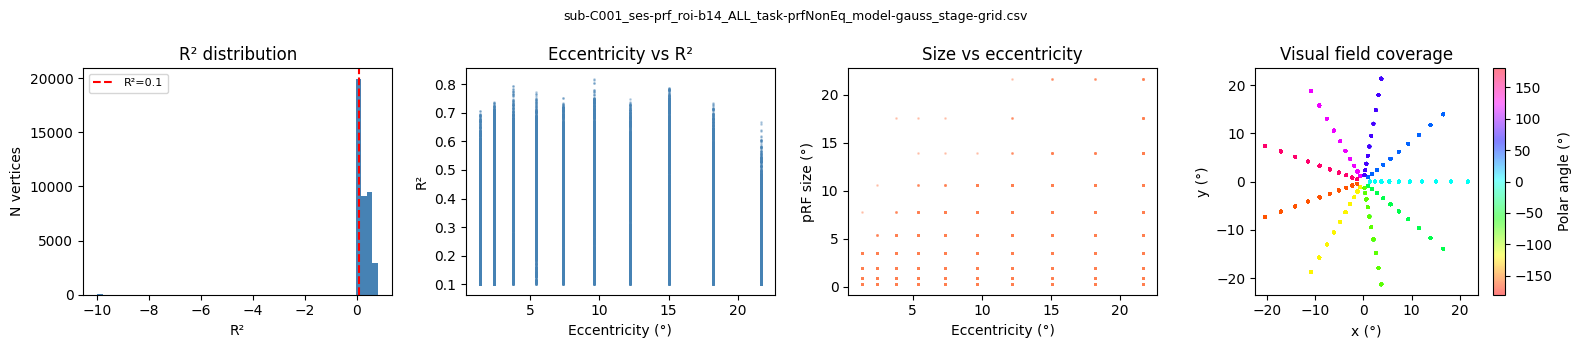

In [13]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bids_dir = os.environ.get('BIDS_DIR', '')
sub      = os.environ.get('SUB', '')
ses      = os.environ.get('SES', '')
prf_task = os.environ.get('PRF_TASK', '')

iter_csvs = sorted(glob.glob(
    os.path.join(bids_dir, 'derivatives', 's5_gauss_prfpy_TEST', sub, '**', '**.csv'),
    recursive=True))

if not iter_csvs:
    print('No iterative fit CSVs found — run Step 1 first.')
else:
    for csv_path in iter_csvs:
        df = pd.read_csv(csv_path)
        name = os.path.basename(csv_path)

        ecc = np.sqrt(df['mu_x']**2 + df['mu_y']**2)
        df['ecc']= ecc
        pol = np.degrees(np.arctan2(df['mu_y'], df['mu_x']))
        df['pol'] = pol
        fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

        # R² distribution
        df['rsq'] =np.clip(df['rsq'], -10, np.inf)
        axes[0].hist(df['rsq'].dropna(), bins=50, color='steelblue', edgecolor='none')
        axes[0].axvline(0.1, color='red', lw=1.5, linestyle='--', label='R²=0.1')
        axes[0].set_xlabel('R²'); axes[0].set_ylabel('N vertices')
        axes[0].set_title('R² distribution'); axes[0].legend(fontsize=8)

        good = df['rsq'] > 0.1
        # Eccentricity vs R²
        axes[1].scatter(ecc[good], df['rsq'][good], s=1, alpha=0.3, color='steelblue')
        axes[1].set_xlabel('Eccentricity (°)'); axes[1].set_ylabel('R²')
        axes[1].set_title('Eccentricity vs R²')

        # pRF size vs eccentricity
        axes[2].scatter(ecc[good], df['size'][good], s=1, alpha=0.3, color='coral')
        axes[2].set_xlabel('Eccentricity (°)'); axes[2].set_ylabel('pRF size (°)')
        axes[2].set_title('Size vs eccentricity')

        # Polar angle map (colour wheel)
        sc = axes[3].scatter(df['mu_x'][good], df['mu_y'][good],
                             c=pol[good], cmap='hsv', s=2, alpha=0.5,
                             vmin=-180, vmax=180)
        plt.colorbar(sc, ax=axes[3], label='Polar angle (°)')
        axes[3].set_xlabel('x (°)'); axes[3].set_ylabel('y (°)')
        axes[3].set_title('Visual field coverage')
        axes[3].set_aspect('equal')

        fig.suptitle(name, fontsize=9)
        print(f'{name}: {good.sum()}/{len(df)} vertices with R²>0.1 ({100*good.mean():.1f}%)')
        plt.tight_layout()
        plt.show()

---
## Step 2 — pRF Visualisation

For interactive surface-based visualisation of pRF maps (eccentricity, polar angle, size, R² plotted on the flatmap), open the dedicated visualisation notebook:

**[`s02_prf_visualize.ipynb`](s02_prf_visualize.ipynb)**

That notebook uses pycortex to render the pRF parameters onto the cortical surface and flatmap. It requires the `pctx` conda environment and the pycortex store to have been set up in the anatomical pipeline (Step 4 of the anatomical walkthrough).

The cell below runs a quick surface plot using matplotlib as a sanity check without requiring pycortex.

In [11]:
from dpu_mini.mesh_maker import GenMeshMaker
from dpu_mini.fs_tools import dpu_load_roi
gm = GenMeshMaker(SUB,os.environ['SUBJECTS_DIR'])
b14_mask = dpu_load_roi(SUB, 'b14_ALL', os.environ['SUBJECTS_DIR'])
gm.make_flat_map(
    b14_mask, cut_circle=0.7, 
)

Using fs dir = /Users/marcusdaghlian/projects/lhon_sl/derivatives/freesurfer
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Adding offset to mesh...
Faces with missing vx: 223723
Faces with long edges: 0
0.19081669560185185
Faces with missing vx: 223501
Faces with long edges: 0
0.19467224928655846


{'cmap': 'viridis',
 'vmin': np.float64(1.3534992980008709),
 'vmax': np.float64(21.655989897257438)}

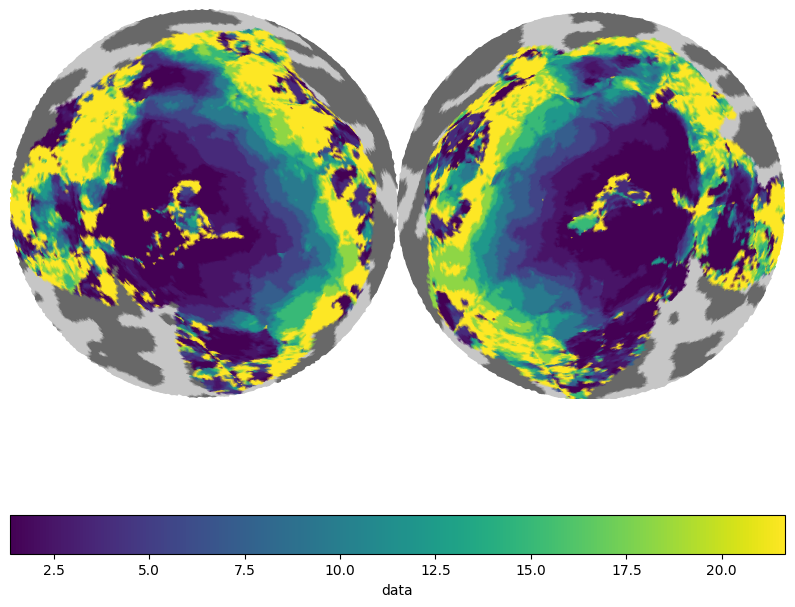

In [15]:
gm.flat_mpl(
    data=df['ecc'], 
    data_sub_mask=b14_mask
)

---
## Step 3 — Connective Field Fitting

### What is a Connective Field?
A Connective Field (CF) model ([Haak et al., 2013](https://doi.org/10.1016/j.neuroimage.2013.03.041)) asks: *given the activity in a source region of cortex (e.g. V1), what weighted combination best predicts the activity of a target vertex elsewhere on the cortex?*

Just as a pRF describes where in visual space a cortical location is tuned, a CF describes where on a source cortical surface it is tuned. It models the connection weight as a 2D Gaussian on the cortical surface, parameterised by:
- **centre** — the vertex in the source region that drives the target most strongly
- **σ (CF size)** — how broadly the Gaussian spreads around that centre (in mm of cortical geodesic distance)
- **β, baseline** — amplitude and baseline of the predicted signal

### Why is this useful?
If you have two runs of the same stimulus presented to different eyes (e.g. `CSFLE` = left eye, `CSFRE` = right eye), you can fit a CF using V1 as the source and ask: which V1 neurons drive a given target vertex, and where are those V1 neurons' receptive fields? This lets you probe the retinotopic organisation of higher areas and inter-areal connectivity without a separate localiser.

### How does the fitting work?
CF fitting uses only a **grid fit** (no iterative refinement) because the parameter space is smaller and the grid fit is usually sufficient:

1. **PSC + concatenate** — runs are converted to PSC and concatenated across time (more data = better estimates)
2. **Geodesic distance matrix** — for all source vertices (e.g. V1), compute pairwise geodesic distances along the pial surface. This is the "ruler" on cortex for defining the CF Gaussian
3. **Grid fit** — for each combination of (centre vertex, σ), generate a predicted timeseries for the target vertex by weighting the source timeseries with the Gaussian. Pick the combination that maximises R²

### Source vs target ROI
- `--roi-src` — the source region whose timeseries are used as predictors (typically `b14_V1.`)
- `--roi-target` — the region whose activity you are trying to explain (e.g. `b14_ALL` to fit all visual areas)
- Source vertices are automatically excluded from the target mask

### Outputs (saved to `derivatives/s6_cf_prfpy/`)
- `*_roisrc-<src>_roitarget-<target>_task-<task>_model-cf.csv` — combined (both hemispheres) CF parameters
- `*_model-cf_hemi-lh.csv` / `*_hemi-rh.csv` — per-hemisphere CSVs

Columns: `index`, `centre`, `prf_size`, `prf_ampl`, `bold_bsl`, `rsq`

> **Note:** The geodesic distance computation (`gdist` step) can take a while for large source regions. It is cached — once computed for a given subject + source ROI it will be reused automatically.

In [18]:
%%bash
# ── Option A: Run locally ─────────────────────────────────────────────────────
# Source: V1 (Benson14)  →  Target: all Benson14 visual areas
# Change --roi-src and --roi-target as needed.

$PYPACKAGE_MANAGER run -n prf \
    python "${PIPELINE_DIR}/postproc/s03_cf_prfpy.py" \
        --bids-dir    "${BIDS_DIR}" \
        --sub         "${SUB}" \
        --ses         "${SES}" \
        --task        "${TASK}" \
        --input-file  s4_denoised_TEST \
        --output-file s6_cf_prfpy \
        --project     "${PROJECT}" \
        --roi-src     b14_V1. \
        --roi-target  b14_ALL

-------------------------------------------------------
 Surface data input  : /Users/marcusdaghlian/projects/lhon_sl/derivatives/s4_denoised_TEST
 Output      : /Users/marcusdaghlian/projects/lhon_sl/derivatives/s6_cf_prfpy
 Subject     : sub-C001
 Session     : ses-prf
 roi target  : b14_ALL
 roi src     : b14_V1.
 hemi        : lh
 
Project lhon, task prfNonEq
 Settings    : {'TR': 1, 'psc_baseline': 19, 'vols_to_chop': 4, 'n_jobs': 4, 'n_batches': 10, 'fitter_args': {'method': 'nelder-mead', 'options': {'maxiter': 1000, 'xatol': 0.001, 'fatol': 0.001}}, 'grid_nr': {'ecc': 10, 'pol': 10, 'size': 10, 'hrf_1': 1}, 'normalize_RFs': False, 'fixed_grid_baseline': None, 'bold_bsl': [-10, 10], 'prf_ampl': [0, 1000], 'rsq_threshold': 0.01, 'hrf': {'pars': [1, 1, 0], 'deriv_bound': [0, 10], 'disp_bound': [0, 0]}, 'screen_size_cm': 27, 'screen_distance_cm': 34, 'eps': '1e-1', 'sigma_grid': [0.5, 1, 2, 3, 4, 5, 7, 10, 15, 20], 'filter_predictions': False, 'norm': {'surround_amplitude_grid': [0

/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/code/hypot_code/cvl_utils/cvl_utils/prf_utils.py:224: RuntimeWarning: divide by zero encountered in divide
  psc_factor = np.nan_to_num( 100 / np.mean(ts, axis=t_dim))

Calculating geodesic distances:   0%|          | 0/4057 [00:00<?, ?it/s]/Users/marcusdaghlian/miniforge3/envs/prf/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve

Calculating geodesic distances: 100%|██████████| 4057/4057 [00:09<00:00, 444.83it/s]

Calculating geodesic distances:   0%|          | 0/4997 [00:00<?, ?it/s]/Users/marcusdaghlian/miniforge3/envs/prf/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve

Calculating geodesic distances: 100%|██████████| 4997/4997 [00:10<00:00, 483.69it/s]



In [31]:
%%bash
# ── Check CF outputs ──────────────────────────────────────────────────────────
echo "=== CF fit CSVs for ${SUB} ==="
find "${BIDS_DIR}/derivatives/s6_cf_prfpy/${SUB}" -name '*.csv' 2>/dev/null \
    || echo "  none found"

=== CF fit CSVs for sub-C001 ===


/Users/marcusdaghlian/projects/lhon_sl/derivatives/s6_cf_prfpy/sub-C001/ses-prf/sub-C001_ses-prf_roisrc-b14_V1._roitarget-b14_ALL_task-prfNonEq_model-cf_hemi-lh.csv
/Users/marcusdaghlian/projects/lhon_sl/derivatives/s6_cf_prfpy/sub-C001/ses-prf/sub-C001_ses-prf_roisrc-b14_V1._roitarget-b14_ALL_task-prfNonEq_model-cf_hemi-rh.csv
/Users/marcusdaghlian/projects/lhon_sl/derivatives/s6_cf_prfpy/sub-C001/ses-prf/sub-C001_ses-prf_roisrc-b14_V1._roitarget-b14_ALL_task-prfNonEq_model-cf.csv


### Quick CF QC — R² distribution and CF size

sub-C001_ses-prf_roisrc-b14_V1._roitarget-b14_ALL_task-prfNonEq_model-cf.csv: 26912/32457 vertices with R²>0.05 (82.9%)


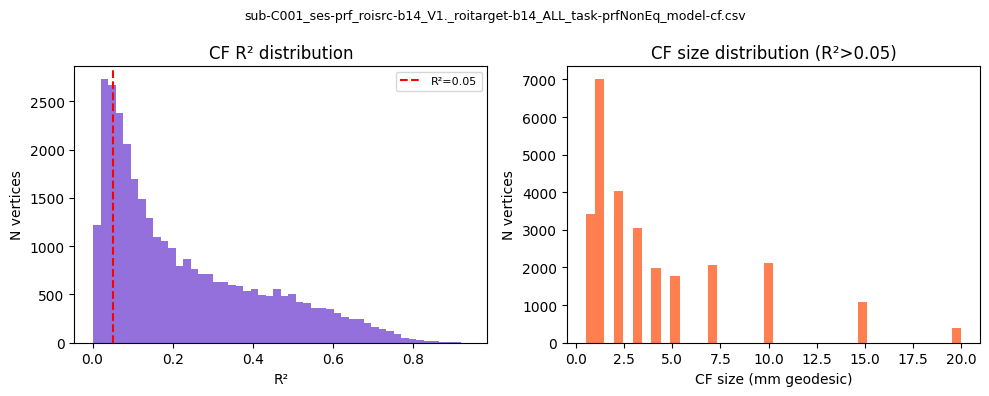

In [33]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bids_dir = os.environ.get('BIDS_DIR', '')
sub      = os.environ.get('SUB', '')

# Load the combined (both hemispheres) CF csv
cf_csvs = sorted(glob.glob(
    os.path.join(bids_dir, 'derivatives', 's6_cf_prfpy', sub, '**', '*model-cf.csv'),
    recursive=True))

if not cf_csvs:
    print('No CF CSVs found — run Step 3 first.')
else:
    for csv_path in cf_csvs:
        df_cf = pd.read_csv(csv_path)
        name = os.path.basename(csv_path)
        good = df_cf['rsq'] > 0.05

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].hist(df_cf['rsq'].dropna(), bins=50, color='mediumpurple', edgecolor='none')
        axes[0].axvline(0.05, color='red', lw=1.5, linestyle='--', label='R²=0.05')
        axes[0].set_xlabel('R²'); axes[0].set_ylabel('N vertices')
        axes[0].set_title('CF R² distribution'); axes[0].legend(fontsize=8)

        axes[1].hist(df_cf['sigma'][good].dropna(), bins=40, color='coral', edgecolor='none')
        axes[1].set_xlabel('CF size (mm geodesic)'); axes[1].set_ylabel('N vertices')
        axes[1].set_title('CF size distribution (R²>0.05)')

        fig.suptitle(name, fontsize=9)
        print(f'{name}: {good.sum()}/{len(df)} vertices with R²>0.05 ({100*good.mean():.1f}%)')
        plt.tight_layout()
        plt.show()

---
## Step 5 — Add benson info to CF



In [42]:
from cvl_utils.preproc_func import *

b14 = load_benson14_info(SUB, os.environ['SUBJECTS_DIR'])
b14_cf_mask = b14_mask.copy()
v1_mask = dpu_load_roi(SUB, 'b14_V1.', os.environ['SUBJECTS_DIR'])
b14_cf_mask[v1_mask] = False
b14_deriv = {}
for k in ['ecc', 'pol']:
    b14_deriv[f'b14{k}'] = np.array([b14[k][int(i)] for i in df_cf['centre']])


{'cmap': 'viridis',
 'vmin': np.float64(0.07350610196590424),
 'vmax': np.float64(85.75083923339844)}

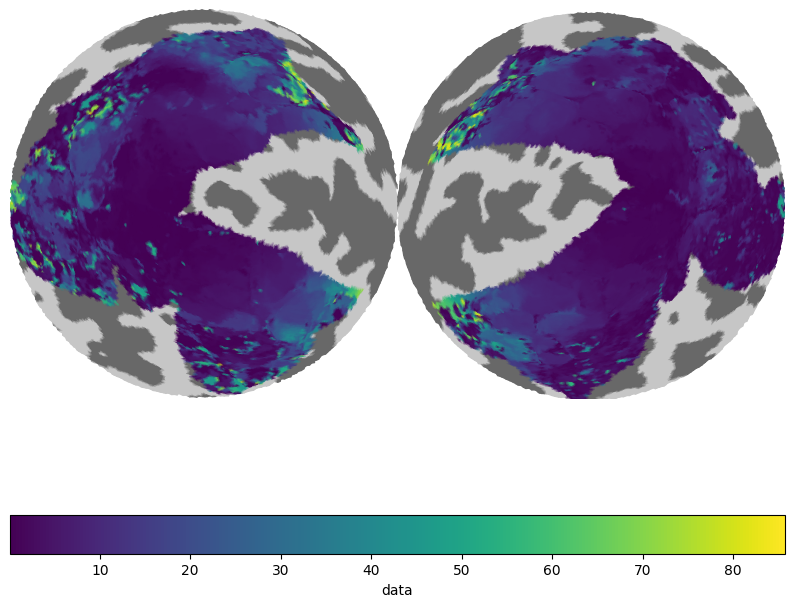

In [44]:
gm.flat_mpl(
    data=b14_deriv['b14ecc'], 
    data_sub_mask=b14_cf_mask,
)